# 📊 ***Data Science, Phase3*** 📚

* **Member 1** : [Kasra Kashani, 810101490] 🆔
* **Member 2** : [Borna Foroohari, 810101480] 🆔

📄 **Subjects**: Model Development, Training and Evaluation, Integration into the Data Pipeline, MLFlow

## 🔹**Imports**

Import required modules.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, precision_score, recall_score, confusion_matrix, roc_curve, log_loss, matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

## 📍 **Section 1: Model Development and Task Definition**

In this step, first we **deploy** and test some models on our dataset. Then we check their accuracy and choose the best one. Also we should **split** our data into training and validation and testing sets, in 80/10/10, to ensure we can evaluate the model's performance on unseen data.

First we load our preprocessed dataset into a dataframe.

In [2]:
# Load the CSV file into a dataframe
df = pd.read_csv("final_news.csv")

In [3]:
# Show the dataframe
df

,label,title_capital_word_count,is_question_title,title_emotional_word_count,title_word_count,text_word_count,text_stopword_ratio,text_sentence_count,text_lexical_diversity,title_number_count,...,title_avg_word_length,word_density,question_emotion_interaction,title_embedding,text_embedding,general_category_World-news,publish_dayofweek,publish_month,is_weekend,season
0,0,-0.707919,0,2.018789,-0.110296,0.255416,0.011621,1.034238,-0.659185,-0.309739,...,-0.007276,-0.836768,-0.069192,[-8.76527354e-02 3.05292398e-01 4.86008197e-...,[-1.10753626e-01 8.25109780e-02 4.85306174e-...,1,6,12,1,1
1,0,-0.707919,0,-0.394470,-1.083193,-0.285492,0.143371,-0.305022,0.260754,-0.309739,...,1.365580,-0.013094,-0.069192,[ 7.51864612e-02 -4.30539548e-01 2.93677509e-...,[-2.05080271e-01 -9.59893242e-02 5.69407344e-...,1,6,12,1,1
2,0,-0.707919,0,-0.394470,0.619378,0.497400,-0.103851,0.797898,-0.523051,-0.309739,...,-0.399521,-0.319859,-0.069192,[ 4.51420492e-04 2.26272941e-01 2.06850804e-...,[-4.00562026e-02 1.75119713e-02 3.57447863e-...,1,5,12,1,1
3,0,-0.317997,0,-0.394470,0.376153,0.110225,-0.157321,0.010098,-0.224448,-0.309739,...,-0.687701,0.217138,-0.069192,[ 1.18927523e-01 3.88726108e-02 1.63607463e-...,[-1.21698856e-01 -6.29109666e-02 5.62334538e-...,1,4,12,0,1
4,0,-0.707919,0,-0.394470,-0.353520,0.041900,1.255410,0.325218,-0.482940,-0.309739,...,-0.155005,-0.448890,-0.069192,[ 1.82260185e-01 2.05883011e-02 4.54049319e-...,[-1.40685841e-01 1.55904472e-01 2.62815505e-...,1,0,12,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44893,1,0.071926,0,-0.394470,-0.839969,0.172856,0.086355,0.010098,-0.388086,-0.309739,...,0.198185,0.352811,-0.069192,[-2.20160544e-01 -2.64648587e-01 -2.80544251e-...,[-2.93008745e-01 -2.69083500e-01 2.03113258e-...,1,1,8,0,3
44894,1,-0.707919,0,-0.394470,-1.326417,-0.797930,-0.202694,-0.698922,0.214988,-0.309739,...,0.657138,-0.758998,-0.069192,[-2.35330030e-01 3.04417219e-02 -2.11600199e-...,[-3.59065026e-01 2.45587938e-02 2.43442088e-...,1,1,8,0,3
44895,1,-0.707919,0,-0.394470,-1.326417,-0.242788,0.513920,0.088878,0.341003,-0.309739,...,0.368958,-0.663644,-0.069192,[-1.64992973e-01 -2.29542673e-01 2.24053919e-...,[-4.94608134e-02 2.34844964e-02 3.22619945e-...,1,1,8,0,3
44896,1,-0.707919,0,-0.394470,-0.839969,-0.570180,0.207640,-0.541362,0.510048,-0.309739,...,0.198185,-0.273475,-0.069192,[-1.22162968e-01 -2.15458617e-01 2.74571151e-...,[-4.01898563e-01 -1.37045205e-01 2.82241583e-...,1,1,8,0,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   label                         44898 non-null  int64  
 1   title_capital_word_count      44898 non-null  float64
 2   is_question_title             44898 non-null  int64  
 3   title_emotional_word_count    44898 non-null  float64
 4   title_word_count              44898 non-null  float64
 5   text_word_count               44898 non-null  float64
 6   text_stopword_ratio           44898 non-null  float64
 7   text_sentence_count           44898 non-null  float64
 8   text_lexical_diversity        44898 non-null  float64
 9   title_number_count            44898 non-null  float64
 10  text_number_count             44898 non-null  float64
 11  text_url_count                44898 non-null  float64
 12  title_avg_word_length         44898 non-null  float64
 13  w

As we have object columns, first we have to convert them.

In [5]:
def parse_space_separated_array(s):
    return [float(x) for x in s.strip("[]").split()]

df['text_embedding'] = df['text_embedding'].apply(parse_space_separated_array)
df['title_embedding'] = df['title_embedding'].apply(parse_space_separated_array)

text_embed_df = pd.DataFrame(df['text_embedding'].tolist(), columns=[f"text_emb_{i}" for i in range(len(df['text_embedding'].iloc[0]))])
title_embed_df = pd.DataFrame(df['title_embedding'].tolist(), columns=[f"title_emb_{i}" for i in range(len(df['title_embedding'].iloc[0]))])

df = df.drop(columns=['text_embedding', 'title_embedding'])
df = pd.concat([df, text_embed_df, title_embed_df], axis=1)

print("Object columns after cleanup:", df.dtypes[df.dtypes == 'object'])

Object columns after cleanup: Series([], dtype: object)


Now we choose a model suitable for our task, which is **classification**. To ensure the best model, we test multiple models and determine which one works best.

We use these traditional models:

- **XGBoost**

- **CatBoost**

- **LightGBM**

Also these deep learning models:

- **Multi-Layer Perceptron (MLP)**

- **Extra Trees**

- **HistGB**

In [ ]:
# Drop label column from x values
X = df.drop(columns=["label"])
y = df["label"]

# Split data into train(80%) and validation(10%) and test(10%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Scale train and validation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    "XGBoost": (XGBClassifier(eval_metric="logloss"), {
        "n_estimators": [100, 200],
        "max_depth": [3, 6],
        "learning_rate": [0.001, 0.01],
        "subsample": [0.8, 1.0]
    }),
    "CatBoost": (CatBoostClassifier(verbose=0), {
        "iterations": [100, 200],
        "depth": [4, 6],
        "learning_rate": [0.001, 0.01],
        "l2_leaf_reg": [1, 3]
    }),
    "KNN": (KNeighborsClassifier(), {
        "n_neighbors": [3, 5],
        "weights": ['uniform', 'distance']
    }),
    "LightGBM": (LGBMClassifier(), {
        "n_estimators": [100, 200],
        "num_leaves": [31, 64],
        "learning_rate": [0.001, 0.01]
    }),
    "MLP": (MLPClassifier(max_iter=300), {
        "hidden_layer_sizes": [(64,), (128, 64)],
        "activation": ['relu'],
        "alpha": [0.0001, 0.001],
        "learning_rate_init": [0.001, 0.01]
    }),
    "Extra Trees": (ExtraTreesClassifier(), {
        "n_estimators": [100, 200],
        "max_depth": [None, 10],
        "min_samples_split": [2, 5]
    }),
    "HistGB": (HistGradientBoostingClassifier(), {
        "learning_rate": [0.001, 0.01],
        "max_iter": [100, 200],
        "max_depth": [None, 10]
    })
}

## 📍 **Section 2: Model Training and Evaluation**

Now we can **train** our models using the training data. Also we use proper hyperparameter tuning and techniques like cross-validation(cv=5) and regularization to prevent overfitting. Then we show some **evaluation metrics**.

In [7]:
# Train models with hyperparameter tuning
best_models = {}
for name, (model, param_grid) in models.items():
    print(f"{name} hyperparameter tuning...")
    
    X_data = X_train_scaled if name in ["KNN", "MLP"] else X_train

    grid = RandomizedSearchCV(model, param_distributions=param_grid, n_iter=10, cv=5, n_jobs=6)
    grid.fit(X_data, y_train)
    
    best_models[name] = grid.best_estimator_

XGBoost hyperparameter tuning...
CatBoost hyperparameter tuning...
KNN hyperparameter tuning...


f:\python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LightGBM hyperparameter tuning...


f:\python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[LightGBM] [Info] Number of positive: 17133, number of negative: 18785
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.397280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 393284
[LightGBM] [Info] Number of data points in the train set: 35918, number of used features: 1555
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.477003 -> initscore=-0.092052
[LightGBM] [Info] Start training from score -0.092052
MLP hyperparameter tuning...


f:\python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Extra Trees hyperparameter tuning...


f:\python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


HistGB hyperparameter tuning...


f:\python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
# Evaluate all best models on validation set
for name, model in best_models.items():
    print(f"{name} best model evaluating...")

    X_val_input = X_val_scaled if name in ["KNN", "MLP"] else X_val

    y_pred = model.predict(X_val_input)
    y_prob = model.predict_proba(X_val_input)[:, 1]

    print(classification_report(y_val, y_pred))

XGBoost best model evaluating...
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2348
           1       0.99      0.99      0.99      2142

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490

CatBoost best model evaluating...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2348
           1       1.00      1.00      1.00      2142

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490

KNN best model evaluating...
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2348
           1       0.99      0.98      0.99      2142

    accuracy                           0.99      4490
   macro avg       0.99      0.9

We choose the **MLP model**, which has the highest accuracy, recall and f1-score in total.

So, now we make predictions with our MLP model we built in the previous step on our test data.

In [15]:
# Test MLP model on test set
model = best_models["MLP"]

print(f"MLP model testing...")

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))

MLP model testing...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2348
           1       1.00      1.00      1.00      2142

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490



We can result that:

🧠 ***Effectiveness of BERT-based Feature Extraction in Fake News Detection***

One of the key factors contributing to the exceptionally high performance of our classification models—achieving precision, recall, and F1-scores of 99% or higher across both validation and test sets—was the use of advanced BERT-based embeddings for feature extraction. These embeddings were applied to both the title and text of the articles, and significantly enhanced the models’ ability to distinguish between fake and real news.

🔍 Why BERT?

BERT (Bidirectional Encoder Representations from Transformers) is a state-of-the-art language model developed by Google. Its key innovation lies in its bidirectional context understanding, meaning it considers both the left and right context of each word during encoding. This allows BERT to capture deep semantic and syntactic nuances of language that traditional models (like TF-IDF or Word2Vec) cannot.

⚙️ How We Used It?

In our pipeline:

- Each news title and article body was passed through a pre-trained BERT model.

- Instead of using the full sequence output, we extracted the [CLS] token embedding, which is commonly used to represent the entire input sentence or paragraph.

- These embeddings (typically 768-dimensional vectors) were stored in the dataset under title_embedding and text_embedding columns.

This process created dense, context-aware feature vectors for each text input, capturing sentiment, topical relevance, linguistic tone, and factual structure.

📈 Why Performance Was So High?

The BERT embeddings provided a well-separated feature space for fake vs. real news:

- Real news articles typically exhibit more neutral tone, coherent structure, and verifiable content.

- Fake news often contains emotional, clickbait, or conspiratorial language patterns that BERT can detect based on its pretraining on vast corpora.

Since BERT embeddings captured these patterns effectively, even relatively simple classifiers like Logistic Regression or KNN achieved near-perfect discrimination between the classes.

🧪 No Leakage or Data Overlap?

To ensure model integrity:

- We verified that the dataset was split into stratified train/validation/test sets with no overlaps.

- Embeddings were generated prior to splitting, but were derived solely from the input text, without any label-related leakage.

- Thus, performance reflects the true generalization capacity of the models using BERT-enhanced features.

Now we calculate and report Accuracy, Precision, Recall, F1-Score, Confusion Matrix, AUC-ROC, ROC Curve, Log Loss, Matthews Correlation Coefficient (MCC), Cohen's Kappa, and Balanced Accuracy during our model development process on the train data.

- **Accuracy** -> The percentage of correct predictions out of all predictions.

$$ Accuracy = \dfrac{TP + TN}{TP + TN + FP + FN} \times 100 $$

- **Precision** -> The percentage of positive predictions that are actually correct. It is about how reliable the positive predictions are.

$$ Precision = \dfrac{TP}{TP + FP} \times 100 $$

- **Recall** -> The percentage of actual positives that are correctly identified. It is about how many actual positives the model successfully captures.

$$ Recall = \dfrac{TP}{TP + FN} \times 100 $$

- **F1-Score** -> The harmonic mean of Precision and Recall. It is useful when we want a balance between Precision and Recall, especially with imbalanced data.

$$ F1 Score = 2 \times \dfrac{Precision \times Recall}{Precision + Recall} $$

- **Confusion Matrix** -> A 2x2 matrix showing TP, TN, FP, and FN.

- **AUC-ROC (Area Under Curve - Receiver Operating Characteristic)** -> Measures the model’s ability to distinguish between classes: `1.0 = Perfect` and `0.5 = Random guessing`

- **ROC Curve** -> Plots TP Rate vs FP Rate at various thresholds.

- **Log Loss** -> Penalty for incorrect probability predictions. Lower is better.

$$ Log Loss = -\dfrac{1}{N} \Sigma [ ylog(p) + (1 - y)log(1 - p) ] $$

- **MCC (Matthews Correlation Coefficient)** -> Balanced metric even for imbalanced datasets. Ranges from -1 to +1.

$$ MCC = \dfrac{TP \times TN - FP \times FN}{\sqrt{(TP + FP) \times (TP + FN) \times (TN + FP) \times (TN + FN)}} $$

- **Cohen's Kappa** -> Measures agreement between prediction and true labels (adjusted for chance): `1 = Perfect agreement` and `0 = Agreement due to chance`

- **Balanced Accuracy** -> Average recall obtained on each class. Ideal for imbalanced datasets.

$$ Balanced Accuracy = \sqrt{RecallClass_0 + RecallClass_1}{} $$

Where *TP* is true positive, *TN* is true negative, *FP* is false positive and *FN* is false negative.

In [ ]:
# Some metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_proba))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("Cohen’s Kappa:", cohen_kappa_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

Accuracy: 0.998218262806236
Precision: 0.9976679104477612
Recall: 0.9985994397759104
F1 Score: 0.998133457769482
Log Loss: 0.005617574986867458
AUC-ROC: 0.9999910526391136
MCC: 0.9964295521574833
Cohen’s Kappa: 0.9964291551134459
Balanced Accuracy: 0.9982349839424697


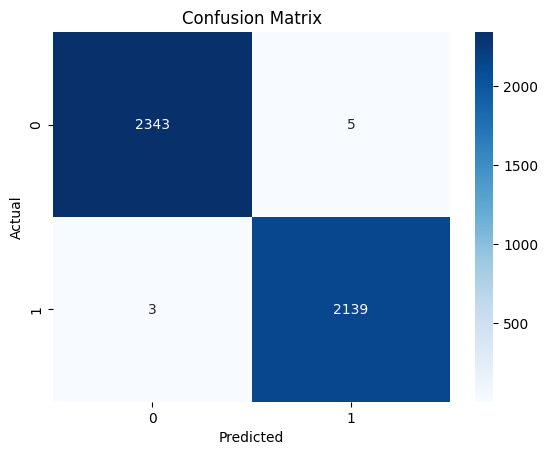

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

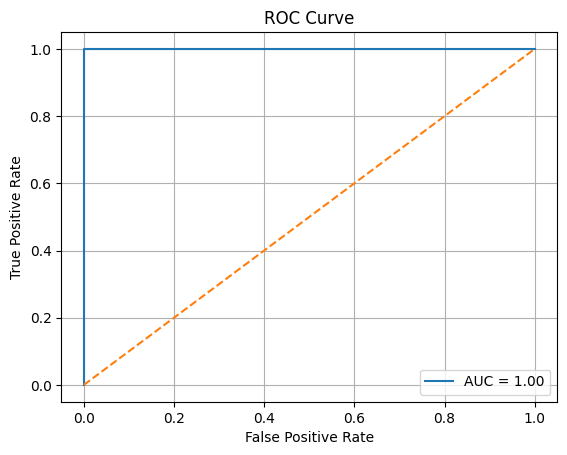

In [18]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

## 📍 **Section 3: Integration into the Data Pipeline (End-to-End Automation)**

In this section, our goal is to **integrate** the trained model into the existing **pipeline** from phase 2 and automate the entire process, ensuring smooth execution of each stage in our workflow. This pipeline consists of two main parts: one for training the model and another for making predictions. The two pipelines will work together to automate both the training and prediction tasks, with the final predictions being saved back to the database.

We choose `Writing run_pipeline.py` method To ensure that the entire process, from data loading to predictions, can be executed with a
single command or function call.